## Loading CIFAR-100

In [ ]:
from pathlib import Path


def project_root() -> Path:
    """Resolve repo root (repo root, notebooks/, or other subfolders)."""
    cwd = Path.cwd().resolve()
    for d in [cwd, *cwd.parents]:
        km = d / "keras_models"
        if km.is_dir() and any(km.glob("*.keras")):
            return d
        if (d / ".git").exists() and (d / "results").is_dir():
            return d
    if (cwd / "datasets").is_dir() or (cwd / "results").is_dir():
        return cwd
    if (cwd.parent / "datasets").is_dir() or (cwd.parent / "results").is_dir():
        return cwd.parent
    return cwd


ROOT = project_root()


In [2]:
import numpy as np
import tensorflow as tf

SEED = 42
IMG_SIZE = 160
BATCH_SIZE = 64
VAL_SIZE = 5_000

USE_AUGMENTATION = False

tf.keras.utils.set_random_seed(SEED)

# Load CIFAR-100 (download automático na 1ª vez)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

# Keep images in [0, 255] (uint8) — each model’s preprocess_input handles scaling
# Squeeze labels to shape (N,) with dtype int
y_train = y_train.squeeze().astype("int64")
y_test = y_test.squeeze().astype("int64")

print("x_train:", x_train.shape, x_train.dtype, "min/max:", x_train.min(), x_train.max())
print("y_train:", y_train.shape, y_train.dtype, "classes:", np.unique(y_train).size)
print("x_test :", x_test.shape, x_test.dtype)
print("y_test :", y_test.shape, y_test.dtype)

# CIFAR-100 fine labels (100 classes)
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver",
    "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly",
    "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach",
    "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox",
    "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard",
    "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid",
    "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum",
    "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew",
    "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table",
    "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe",
    "whale", "willow_tree", "wolf", "woman", "worm",
]
print("Example label:", int(y_train[0]), "->", class_names[int(y_train[0])])

x_train: (50000, 32, 32, 3) uint8 min/max: 0 255
y_train: (50000,) int64 classes: 100
x_test : (10000, 32, 32, 3) uint8
y_test : (10000,) int64
Exemplo de rótulo: 19 -> cattle


## Preparação do dataset (train/val/test)

In [3]:
AUTOTUNE = tf.data.AUTOTUNE

# Split train into train/val (last VAL_SIZE examples = validation)
x_val = x_train[-VAL_SIZE:]
y_val = y_train[-VAL_SIZE:]
x_tr = x_train[:-VAL_SIZE]
y_tr = y_train[:-VAL_SIZE]

print("train:", x_tr.shape, y_tr.shape)
print("val  :", x_val.shape, y_val.shape)
print("test :", x_test.shape, y_test.shape)


def preprocess_image(image, label, training: bool):
    # uint8 [0,255] -> float32
    image = tf.cast(image, tf.float32)

    if training and USE_AUGMENTATION:
        # Classic CIFAR augmentation: pad + random crop + flip
        image = tf.image.resize_with_crop_or_pad(image, 40, 40)
        image = tf.image.random_crop(image, size=[32, 32, 3])
        image = tf.image.random_flip_left_right(image)

    # Resize to backbone size (keeps a clean graph for TFLite)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE), method="bilinear")

    return image, label


def make_ds(x, y, training: bool):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10_000, seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(lambda im, lab: preprocess_image(im, lab, training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_ds(x_tr, y_tr, training=True)
val_ds = make_ds(x_val, y_val, training=False)
test_ds = make_ds(x_test, y_test, training=False)

train: (45000, 32, 32, 3) (45000,)
val  : (5000, 32, 32, 3) (5000,)
test : (10000, 32, 32, 3) (10000,)


## Common settings (all models)

Esta cell concentra tudo que é compartilhado entre os models (augmentação, callbacks, hiperparâmetros e funções auxiliares). Para testar novos models (ex.: MCU-Net), basta criar um `build_*()` e chamar `train_head_and_finetune(...)`.

In [4]:
from pathlib import Path
from tensorflow.keras import layers

# The dataset already yields (IMG_SIZE, IMG_SIZE, 3) so the model input is fixed.
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
NUM_CLASSES = 100

# Training (shared)
EPOCHS_HEAD = 40
EPOCHS_FINE = 20
HEAD_LR = 1e-3
FINE_LR = 1e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
FINE_TUNE_RATIO = 0.8

CHECKPOINT_DIR = ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

base_callbacks = [
    tf.keras.callbacks.TerminateOnNaN(),
    # Patience > ReduceLROnPlateau.patience para dar tempo do LR cair antes de parar
    tf.keras.callbacks.EarlyStopping(
        patience=8,
        restore_best_weights=True,
        monitor="val_accuracy",
        mode="max",
        min_delta=1e-3,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=3,
        factor=0.5,
        min_lr=1e-6,
        monitor="val_loss",
        verbose=1,
    ),
]


def make_common_stem(preprocess_layer: tf.keras.layers.Layer):
    """Build Input + a preprocess layer for the model.

    Prefer using **Keras layers** (not a Python `Lambda`) so the model is
    easy to save/load as `.keras` without extra `custom_objects`.
    """
    inputs = tf.keras.Input(shape=INPUT_SHAPE)
    x = preprocess_layer(inputs)
    return inputs, x


def make_sparse_ce_with_label_smoothing(label_smoothing: float):
    """Label smoothing for sparse (int) labels.

    Some versions don’t support `label_smoothing` in SparseCategoricalCrossentropy.
    Aqui fazemos smoothing convertendo y_true -> one-hot dentro da loss.
    """

    if not label_smoothing or label_smoothing <= 0.0:
        return tf.keras.losses.SparseCategoricalCrossentropy()

    cce = tf.keras.losses.CategoricalCrossentropy()

    def loss(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true = tf.one_hot(y_true, depth=NUM_CLASSES)
        y_true = y_true * (1.0 - label_smoothing) + (label_smoothing / NUM_CLASSES)
        return cce(y_true, y_pred)

    return loss


def make_optimizer(lr: float, weight_decay: float):
    """AdamW when available; otherwise Adam."""

    AdamW = getattr(tf.keras.optimizers, "AdamW", None)
    if AdamW is not None:
        return AdamW(learning_rate=lr, weight_decay=weight_decay)
    return tf.keras.optimizers.Adam(learning_rate=lr)


KERAS_MODELS_DIR = ROOT / "keras_models"
KERAS_MODELS_DIR.mkdir(parents=True, exist_ok=True)


def save_best_as_keras(build_fn, results: dict, filename: str):
    """Reload the uncompiled model, load best weights, and save a `.keras` file.

    This avoids common training serialization issues (custom loss, etc.).
    """

    weights_path = results.get("best_weights")
    if not weights_path:
        raise ValueError("results does not have 'best_weights'. Run training first.")

    model, _ = build_fn()
    model.load_weights(weights_path)

    out_path = KERAS_MODELS_DIR / filename
    model.save(str(out_path))
    print("Model salvo em:", out_path.resolve())
    return out_path, model


def predict_labels(model: tf.keras.Model, ds):
    """Retorna y_true, y_pred e a matriz de probabilidades."""

    y_true = []
    y_prob = []
    for xb, yb in ds:
        prob = model.predict(xb, verbose=0)
        y_prob.append(prob)
        y_true.append(yb.numpy())

    y_true = np.concatenate(y_true).astype("int64")
    y_prob = np.concatenate(y_prob)
    y_pred = y_prob.argmax(axis=1).astype("int64")
    return y_true, y_pred, y_prob


def metrics_from_confusion_matrix(cm: np.ndarray):
    """Classic metrics from the confusion matrix."""

    cm = cm.astype(np.int64)
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    fp = cm.sum(axis=0) - tp
    fn = support - tp

    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / np.maximum(tp + fn, 1)
    f1 = (2 * precision * recall) / np.maximum(precision + recall, 1e-12)
    per_class_acc = tp / np.maximum(support, 1)

    acc = tp.sum() / np.maximum(cm.sum(), 1)
    macro_f1 = f1.mean()
    weighted_f1 = (f1 * support).sum() / np.maximum(support.sum(), 1)

    return {
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "per_class_accuracy": per_class_acc,
        "per_class_f1": f1,
        "per_class_precision": precision,
        "per_class_recall": recall,
        "support": support,
    }


def plot_per_class_accuracy_heatmap(per_class_acc: np.ndarray, class_names: list[str], title: str):
    import matplotlib.pyplot as plt

    per_class_acc = np.asarray(per_class_acc)

    fig, ax = plt.subplots(figsize=(20, 1.6))
    im = ax.imshow(per_class_acc[None, :], aspect="auto", cmap="viridis", vmin=0, vmax=1)

    ax.set_yticks([0])
    ax.set_yticklabels(["acc"])
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90, ha="center", fontsize=6)

    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    ax.set_title(title)
    fig.tight_layout()


def plot_confusion_matrix_heatmap(cm: np.ndarray, class_names: list[str], title: str, normalize: bool = True):
    import matplotlib.pyplot as plt

    cm = cm.astype(np.float32)
    if normalize:
        cm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig, ax = plt.subplots(figsize=(18, 16))
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1 if normalize else cm.max())

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90, ha="center", fontsize=5)
    ax.set_yticklabels(class_names, fontsize=5)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Verdadeiro")
    ax.set_title(title)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()


def evaluate_model(model: tf.keras.Model, ds, class_names: list[str], title: str):
    y_true, y_pred, _ = predict_labels(model, ds)
    cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(class_names)).numpy()

    m = metrics_from_confusion_matrix(cm)
    print(f"[{title}] accuracy={m['accuracy']:.4f} | macro_f1={m['macro_f1']:.4f} | weighted_f1={m['weighted_f1']:.4f}")

    # Per-class (resumo das 10 melhores e 10 piores)
    sorted_idx = np.argsort(m['per_class_accuracy'])
    print("\n  10 piores classes:")
    for i in sorted_idx[:10]:
        print(
            f"    {class_names[i]:>15s}: acc={m['per_class_accuracy'][i]:.3f} "
            f"f1={m['per_class_f1'][i]:.3f} support={int(m['support'][i])}"
        )
    print("\n  10 melhores classes:")
    for i in sorted_idx[-10:]:
        print(
            f"    {class_names[i]:>15s}: acc={m['per_class_accuracy'][i]:.3f} "
            f"f1={m['per_class_f1'][i]:.3f} support={int(m['support'][i])}"
        )

    plot_per_class_accuracy_heatmap(m["per_class_accuracy"], class_names, title=f"{title} — accuracy por classe")
    plot_confusion_matrix_heatmap(cm, class_names, title=f"{title} — confusion matrix (normalizada)", normalize=True)
    return m, cm


def train_head_and_finetune(
    model: tf.keras.Model,
    base: tf.keras.Model | None,
    model_tag: str,
    head_epochs: int = EPOCHS_HEAD,
    fine_epochs: int = EPOCHS_FINE,
    head_lr: float = HEAD_LR,
    fine_lr: float = FINE_LR,
    weight_decay: float = WEIGHT_DECAY,
    label_smoothing: float = LABEL_SMOOTHING,
    fine_tune_ratio: float = FINE_TUNE_RATIO,
):
    """Train the head (frozen base) then fine-tune partially (if base is not None).

    - Usa AdamW + label smoothing
    - Keeps the best val_accuracy checkpoint (handy to export/convert later).
    """

    ckpt_path = CHECKPOINT_DIR / f"{model_tag.replace(' ', '_')}_best.weights.h5"
    ckpt_cb = tf.keras.callbacks.ModelCheckpoint(
        ckpt_path,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )
    callbacks = base_callbacks + [ckpt_cb]

    loss_fn = make_sparse_ce_with_label_smoothing(label_smoothing)
    metrics = [
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5"),
    ]

    # Head
    model.compile(
        optimizer=make_optimizer(head_lr, weight_decay),
        loss=loss_fn,
        metrics=metrics,
    )

    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=head_epochs,
        callbacks=callbacks,
    )

    # Fine-tune (2nd training phase when base=None)
    history_ft = None
    if fine_epochs > 0:
        if base is not None:
            base.trainable = True

            fine_tune_at = int(len(base.layers) * fine_tune_ratio)
            for layer in base.layers[:fine_tune_at]:
                layer.trainable = False

            # Keep BatchNorm in inference mode during fine-tuning (common practice)
            for layer in base.layers[fine_tune_at:]:
                if isinstance(layer, layers.BatchNormalization):
                    layer.trainable = False

        model.compile(
            optimizer=make_optimizer(fine_lr, weight_decay),
            loss=loss_fn,
            metrics=metrics,
        )

        history_ft = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=fine_epochs,
            callbacks=callbacks,
        )

    # Garante que vamos avaliar o melhor checkpoint salvo (pesos)
    model.load_weights(ckpt_path)
    loss_test, acc_test, top5_test = model.evaluate(test_ds, verbose=0)

    print(f"[{model_tag}] Test acc (best weights): {acc_test:.4f} | top5: {top5_test:.4f} | loss: {loss_test:.4f}")

    return {
        "test_acc_head": float("nan"),
        "test_loss_head": float("nan"),
        "test_acc_finetune": float(acc_test),
        "test_loss_finetune": float(loss_test),
        "test_top5": float(top5_test),
        "best_weights": str(ckpt_path),
    }, history_head, history_ft

## MobileNetV3-Small

In [4]:
from tensorflow.keras.applications import MobileNetV3Small


def build_mobilenetv3_small(num_classes: int = NUM_CLASSES, dropout: float = 0.2):
    # Dataset output is float32 in [0, 255]
    preprocess = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="preprocess_mnv3")
    inputs, x = make_common_stem(preprocess)

    base = MobileNetV3Small(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_preprocessing=False,  # we already rescale to (-1, 1) above
    )
    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="MobileNetV3Small_CIFAR100")
    return model, base


mobilenet_model, mobilenet_base = build_mobilenetv3_small()
mnv3_results, history_mnv3_head, history_mnv3_ft = train_head_and_finetune(
    mobilenet_model,
    mobilenet_base,
    model_tag="MobileNetV3-Small",
)

C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\Lightweight Analyses\.venv\anonymous\anonymous\anonymous\anonymous\anonymous\mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 127s 174ms/step - accuracy: 0.4644 - loss: 2.6121 - top5: 0.7568 - val_accuracy: 0.6094 - val_loss: 2.0907 - val_top5: 0.8762 - learning_rate: 0.0010
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 120s 170ms/step - accuracy: 0.6201 - loss: 2.0523 - top5: 0.8858 - val_accuracy: 0.6424 - val_loss: 1.9765 - val_top5: 0.8930 - learning_rate: 0.0010
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 196ms/step - accuracy: 0.6514 - loss: 1.9542 - top5: 0.9027 - val_accuracy: 0.6460 - val_loss: 1.9396 - val_top5: 0.9044 - learning_rate: 0.0010
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 136s 187ms/step - accuracy: 0.6701 - loss: 1.9022 - top5: 0.9125 - val_accuracy: 0.6634 - val_loss: 1.9110 - val_top5: 0.9070 - learning_rate: 0.0010
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 191ms/step - accuracy: 0.6806 - loss: 1.8770 - top5: 0.9144 - val_accuracy: 0.6586 - val_loss: 1.9100 - val_top5: 0.9068 - learning_rate: 0.0010
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 126s 178ms

In [5]:
# Save the best model as .keras and evaluate (accuracy, F1, heatmaps)
mnv3_keras_path, mnv3_keras_model = save_best_as_keras(
    build_mobilenetv3_small,
    mnv3_results,
    filename="MobileNetV3Small_CIFAR100.keras",
)

Model salvo em: C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\Lightweight Analyses\anonymous\MobileNetV3Small_CIFAR100.keras


[MobileNetV3-Small] accuracy=0.7301 | macro_f1=0.7293 | weighted_f1=0.7293

  10 piores classes:
                boy: acc=0.440 f1=0.468 support=100
               girl: acc=0.460 f1=0.458 support=100
              otter: acc=0.460 f1=0.489 support=100
              woman: acc=0.460 f1=0.484 support=100
              mouse: acc=0.490 f1=0.519 support=100
             possum: acc=0.520 f1=0.581 support=100
               seal: acc=0.520 f1=0.536 support=100
            lobster: acc=0.550 f1=0.545 support=100
               bear: acc=0.550 f1=0.573 support=100
             rabbit: acc=0.590 f1=0.584 support=100

  10 melhores classes:
              apple: acc=0.890 f1=0.899 support=100
            tractor: acc=0.900 f1=0.849 support=100
              skunk: acc=0.910 f1=0.879 support=100
             orange: acc=0.920 f1=0.889 support=100
         television: acc=0.920 f1=0.885 support=100
         chimpanzee: acc=0.930 f1=0.857 support=100
               road: acc=0.930 f1=0.925 support

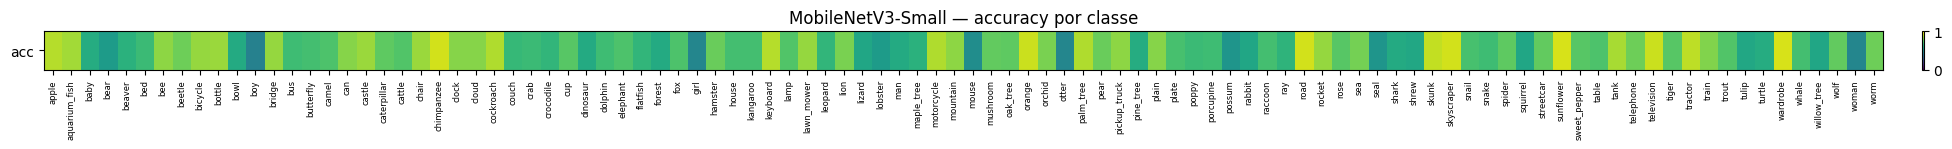

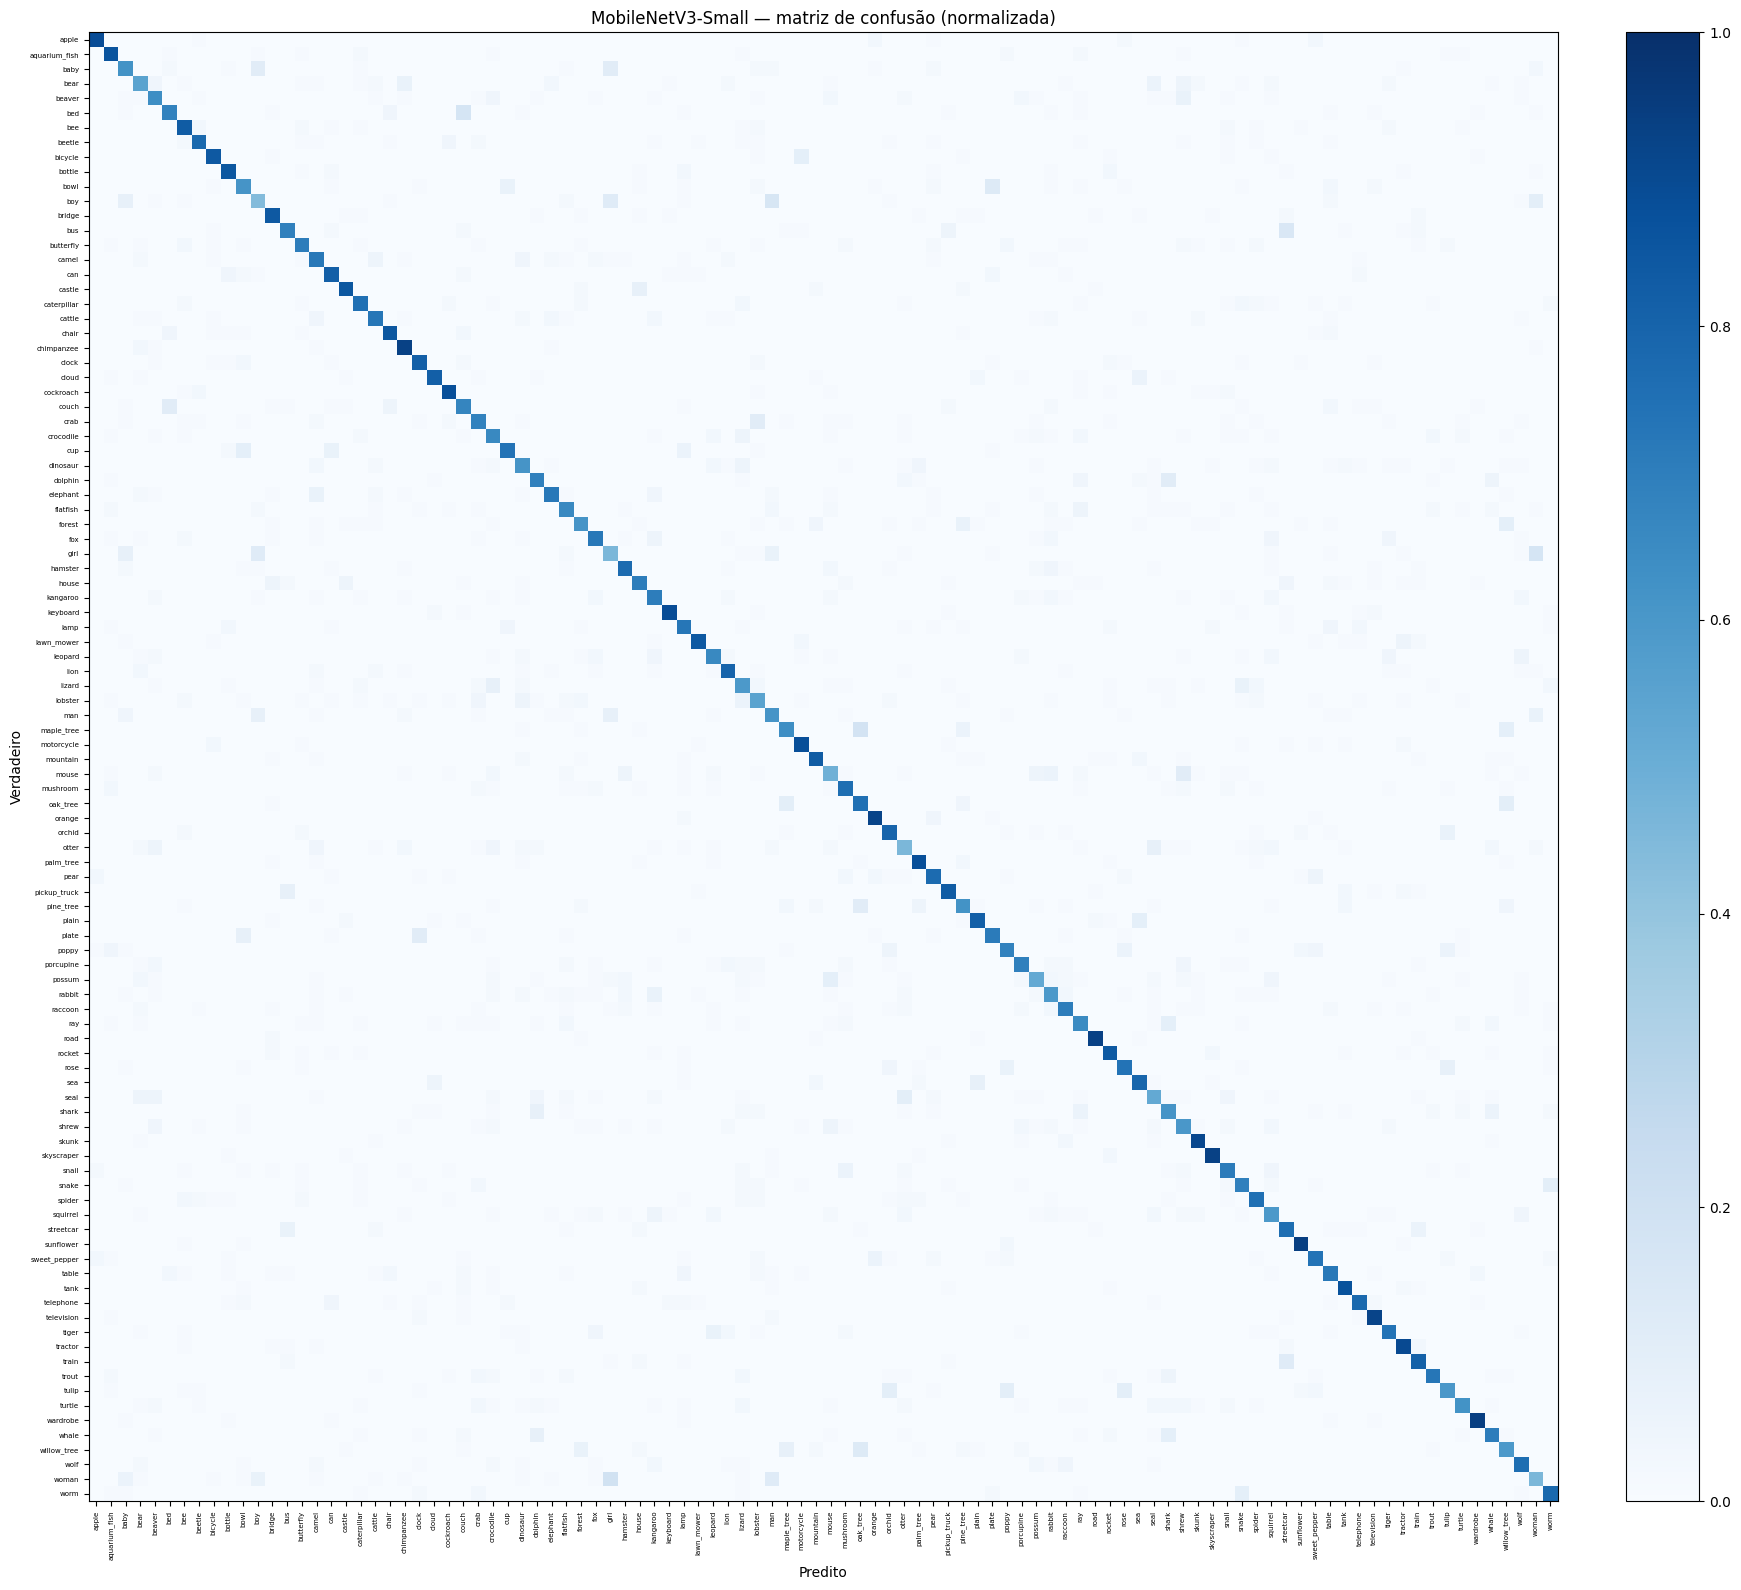

In [6]:
mnv3_eval, mnv3_cm = evaluate_model(mnv3_keras_model, test_ds, class_names, title="MobileNetV3-Small")

## EfficientNetB0

In [7]:
import inspect
from tensorflow.keras.applications import EfficientNetB0


def build_efficientnetb0(num_classes: int = NUM_CLASSES, dropout: float = 0.3):
    preprocess = layers.Identity(name="preprocess_effnet_identity")
    inputs, x = make_common_stem(preprocess)

    eff_kwargs = dict(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    # Evita dupla normalização se sua versão tiver preprocessing embutido
    if "include_preprocessing" in inspect.signature(EfficientNetB0).parameters:
        eff_kwargs["include_preprocessing"] = False

    base = EfficientNetB0(**eff_kwargs)
    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="EfficientNetB0_CIFAR100")
    return model, base


effnet_model, effnet_base = build_efficientnetb0()

effnet_results, history_eff_head, history_eff_ft = train_head_and_finetune(
    effnet_model,
    effnet_base,
    model_tag="EfficientNetB0",
)

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 533s 731ms/step - accuracy: 0.5738 - loss: 2.2415 - top5: 0.8394 - val_accuracy: 0.6842 - val_loss: 1.8077 - val_top5: 0.9172 - learning_rate: 0.0010
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 546s 775ms/step - accuracy: 0.6946 - loss: 1.7856 - top5: 0.9215 - val_accuracy: 0.6964 - val_loss: 1.7571 - val_top5: 0.9238 - learning_rate: 0.0010
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.7209 - loss: 1.6993 - top5: 0.9349
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 492s 699ms/step - accuracy: 0.7214 - loss: 1.7032 - top5: 0.9341 - val_accuracy: 0.7088 - val_loss: 1.7277 - val_top5: 0.9254 - learning_rate: 0.0010
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 477s 678ms/step - accuracy: 0.7483 - loss: 1.6325 - top5: 0.9465 - val_accuracy: 0.7166 - val_loss: 1.7095 - val_top5: 0.9288 - learning_rate: 5.0000e-04
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 487s 692ms/step - accuracy: 

In [8]:
# Save the best model as .keras and evaluate (accuracy, F1, heatmaps)
effb0_keras_path, effb0_keras_model = save_best_as_keras(
    build_efficientnetb0,
    effnet_results,
    filename="EfficientNetB0_CIFAR100.keras",
)

Model salvo em: C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\Lightweight Analyses\anonymous\EfficientNetB0_CIFAR100.keras


[EfficientNetB0] accuracy=0.7832 | macro_f1=0.7829 | weighted_f1=0.7829

  10 piores classes:
                boy: acc=0.510 f1=0.551 support=100
             possum: acc=0.510 f1=0.586 support=100
              mouse: acc=0.520 f1=0.515 support=100
               girl: acc=0.530 f1=0.552 support=100
              otter: acc=0.540 f1=0.540 support=100
               bear: acc=0.560 f1=0.583 support=100
               seal: acc=0.560 f1=0.549 support=100
        willow_tree: acc=0.600 f1=0.609 support=100
              woman: acc=0.610 f1=0.578 support=100
                man: acc=0.620 f1=0.602 support=100

  10 melhores classes:
           keyboard: acc=0.910 f1=0.915 support=100
         chimpanzee: acc=0.920 f1=0.836 support=100
         television: acc=0.920 f1=0.889 support=100
              skunk: acc=0.920 f1=0.915 support=100
            tractor: acc=0.920 f1=0.915 support=100
          sunflower: acc=0.930 f1=0.949 support=100
           wardrobe: acc=0.950 f1=0.931 support=10

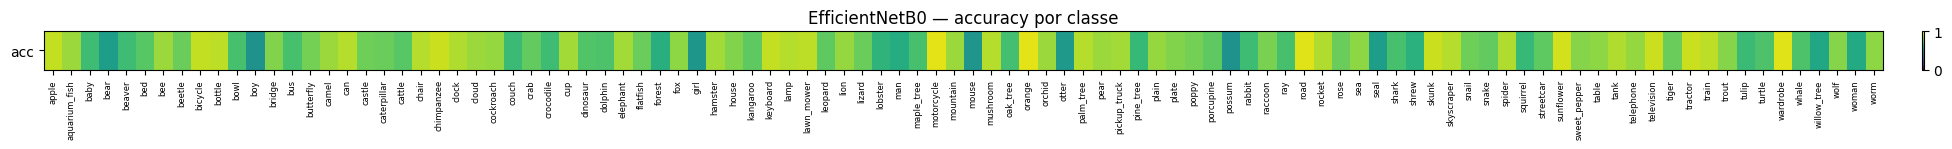

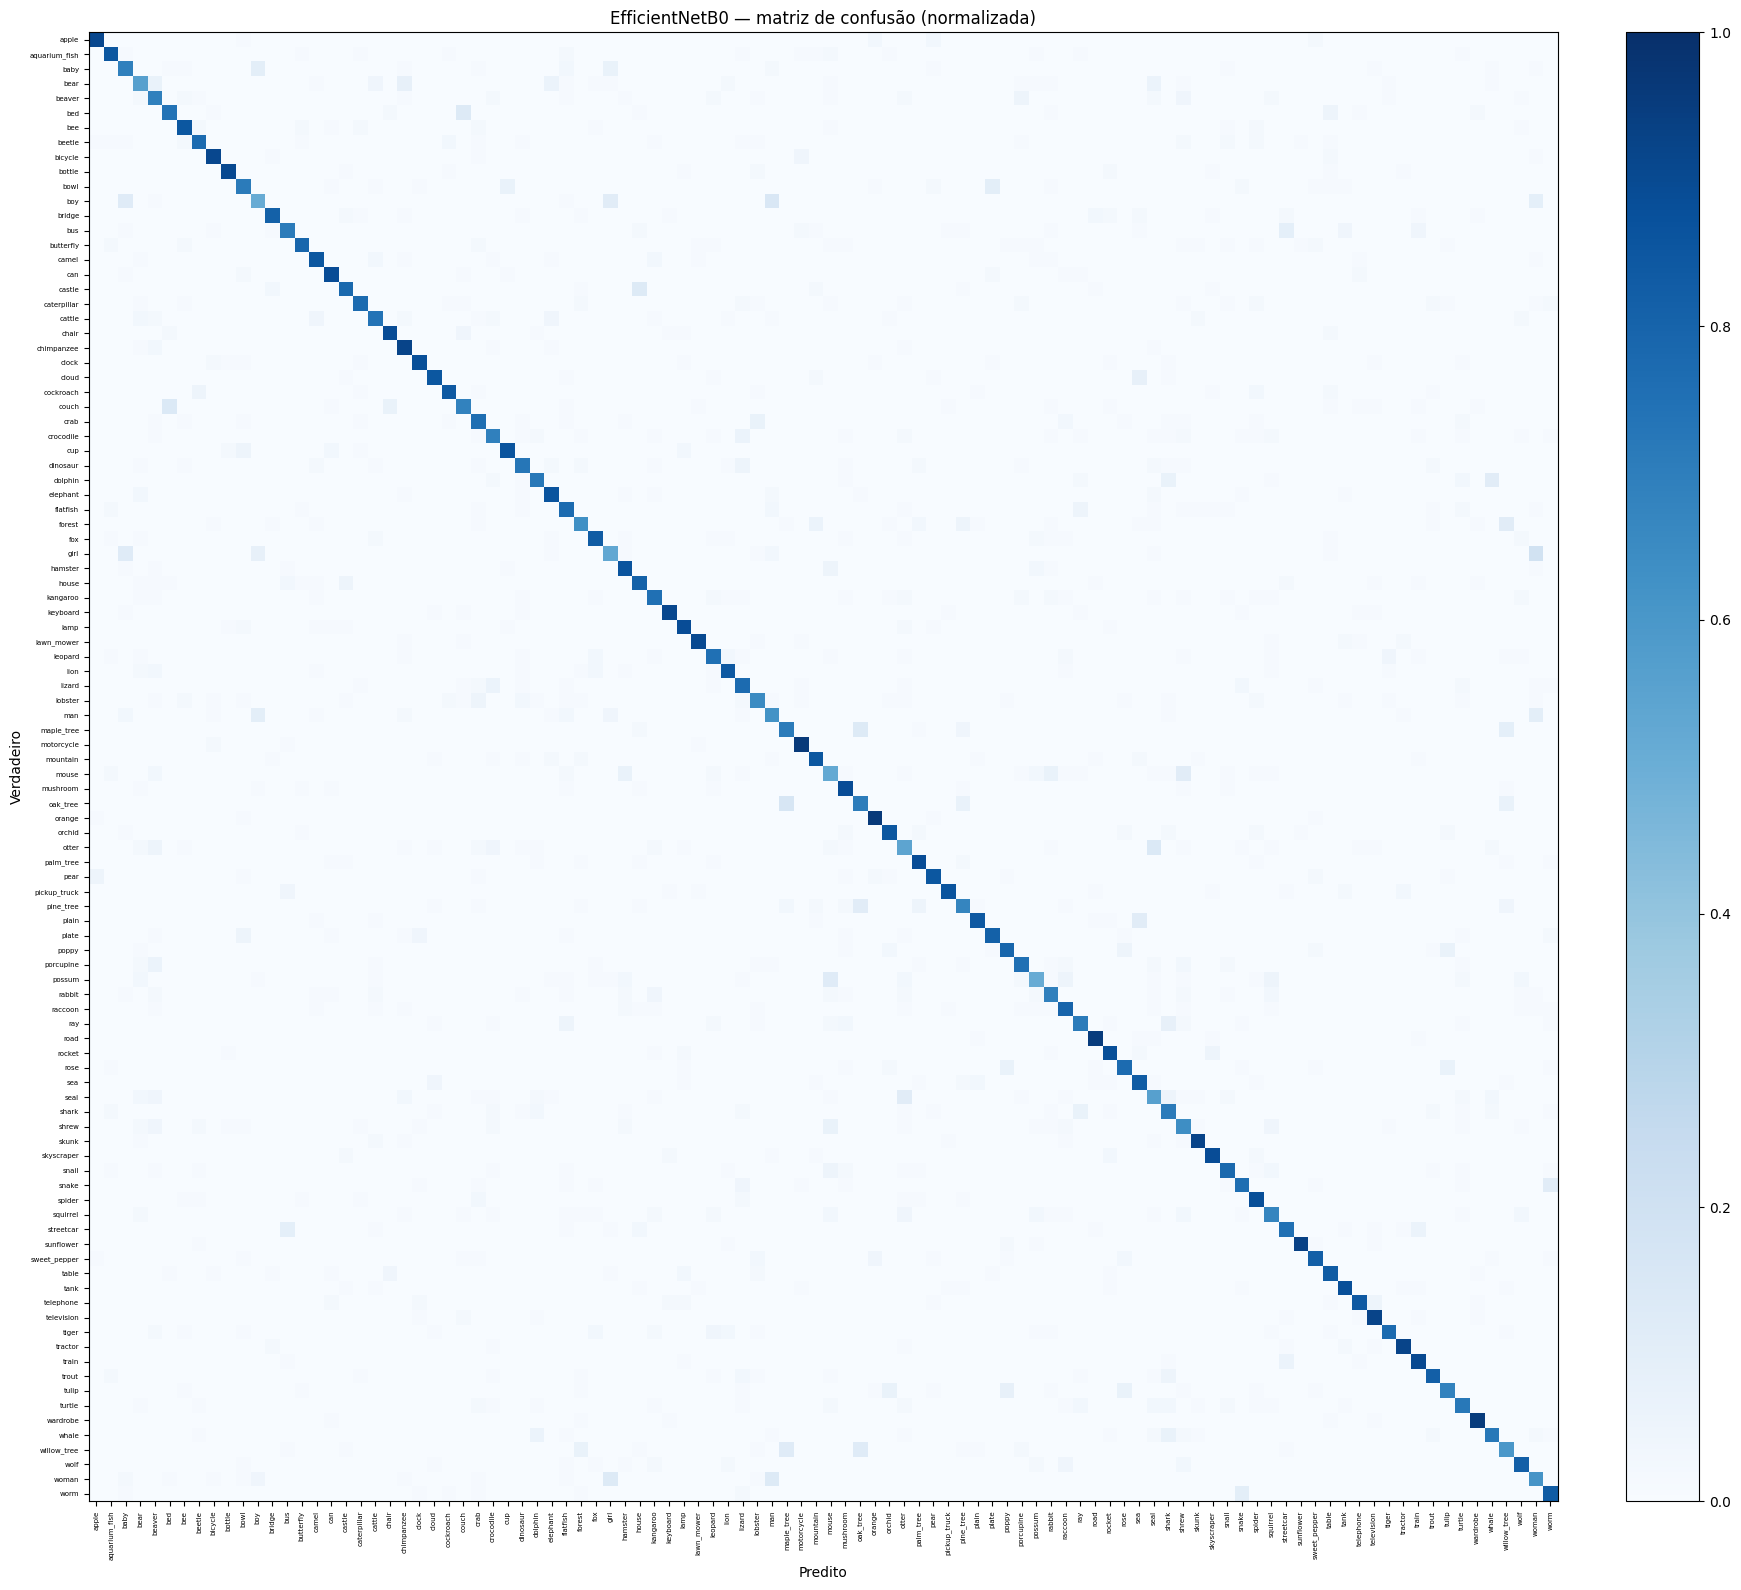

In [9]:
effb0_eval, effb0_cm = evaluate_model(effb0_keras_model, test_ds, class_names, title="EfficientNetB0")

## MCUNet Oficial (mit-han-lab/mcunet)

We use the **official MCUNet** repo (`third_party/mcunet-official`), which provides:
- Models pré-treinados no ImageNet (PyTorch)
- Suporte a download automático de configs e pesos
- Arquitetura ProxylessNAS otimizada para microcontroladores

Workflow:
1. Load the pre-trained PyTorch model do ImageNet
2. Converter os pesos para Keras
3. Fazer fine-tuning no CIFAR-100

In [6]:
import sys
import json
import torch
import numpy as np
from pathlib import Path

# Adiciona o caminho do MCUNet oficial ao path
MCUNET_OFFICIAL_PATH = Path("third_party/mcunet-official")
if str(MCUNET_OFFICIAL_PATH) not in sys.path:
    sys.path.insert(0, str(MCUNET_OFFICIAL_PATH))

from mcunet.model_zoo import build_model as build_mcunet_pytorch, net_id_list, download_tflite

# =====================================================================
# Custom ImageNet normalization layer (registered for serialization)
# =====================================================================
# Compatível com TF < 2.16 (Keras 2) e TF >= 2.16 (Keras 3)
_register = getattr(tf.keras.utils, 'register_keras_serializable', None) or \
            getattr(tf.keras.saving, 'register_keras_serializable', None)

@_register(package="MCUNet")
class ImageNetNormalization(layers.Layer):
    """ImageNet normalization: (x/255 - mean) / std"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
        self.std = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)
    
    def call(self, x):
        x = x / 255.0
        return (x - self.mean) / self.std
    
    def get_config(self):
        return super().get_config()

print("=" * 70)
print("MCUNet (official) — available models:")
print("=" * 70)
for net_id in net_id_list:
    print(f"  - {net_id}")

# =====================================================================
# Escolha do model MCUNet
# =====================================================================
# Opções ImageNet: mcunet-in0 (10fps), mcunet-in1 (5fps), mcunet-in2, mcunet-in3, mcunet-in4
# mcunet-in4 (512KB SRAM, 2MB Flash) is the largest variant—best for apples-to-apples comparison
MCUNET_NET_ID = "mcunet-in4"

print(f"\nLoading model: {MCUNET_NET_ID}")
pt_model, resolution, description = build_mcunet_pytorch(MCUNET_NET_ID, pretrained=True)
print(f"Native resolution: {resolution}x{resolution}")
print(f"Description: {description}")
pt_model.eval()

# Exibe arquitetura resumida
total_params = sum(p.numel() for p in pt_model.parameters())
trainable_params = sum(p.numel() for p in pt_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

MCUNet Oficial - Models disponíveis:
  - mcunet-in0
  - mcunet-in1
  - mcunet-in2
  - mcunet-in3
  - mcunet-in4
  - mbv2-w0.35
  - proxyless-w0.3
  - mcunet-vww0
  - mcunet-vww1
  - mcunet-vww2
  - person-det

Loading model: mcunet-in4
Native resolution: 160x160
Description: MCUNet model that fits 512KB SRAM and 2MB Flash (ImageNet)
Total parameters: 1,732,640
Trainable parameters: 1,732,640


In [5]:
def build_mcunet_official(
    num_classes: int = NUM_CLASSES,
    dropout: float = 0.2,
    net_id: str = MCUNET_NET_ID,
):
    """
    Build a Keras model from the official MCUNet architecture.
    
    Load ImageNet pre-trained PyTorch weights and convert to Keras.
    Returns (full_model, backbone) for train_head_and_finetune.
    """
    # Load PyTorch model with pre-trained weights
    pt_model, resolution, _ = build_mcunet_pytorch(net_id, pretrained=True)
    pt_model.eval()
    pt_state = pt_model.state_dict()
    
    # Read network config
    net_config = pt_model.config
    
    # BatchNorm parameters
    bn_momentum = 0.9  # Keras default (PyTorch usa 0.1, que é 1-0.9)
    bn_eps = 1e-5
    
    # ========== CONSTRUÇÃO DO MODELO KERAS ==========
    
    # Usa a classe ImageNetNormalization registrada externamente
    preprocess = ImageNetNormalization(name="preprocess_mcunet_official")
    inputs, x = make_common_stem(preprocess)
    
    # Activation helper
    def _act(x, act_name, name):
        if act_name in (None, "none"):
            return x
        if act_name == "relu6":
            return layers.ReLU(max_value=6.0, name=name)(x)
        if act_name == "relu":
            return layers.ReLU(name=name)(x)
        return x
    
    # First conv
    first_conv_cfg = net_config.get("first_conv", {})
    out_ch = first_conv_cfg.get("out_channels", 32)
    ks = first_conv_cfg.get("kernel_size", 3)
    stride = first_conv_cfg.get("stride", 2)
    act = first_conv_cfg.get("act_func", "relu6")
    
    x = layers.Conv2D(out_ch, ks, strides=stride, padding="same", use_bias=False, 
                      name="mcunet_off_first_conv")(x)
    x = layers.BatchNormalization(momentum=bn_momentum, epsilon=bn_eps, 
                                  name="mcunet_off_first_bn")(x)
    x = _act(x, act, name="mcunet_off_first_act")
    
    # MBConv blocks
    blocks_cfg = net_config.get("blocks", [])
    for i, block in enumerate(blocks_cfg):
        mic = block.get("mobile_inverted_conv", {})
        if not mic or mic.get("name") == "ZeroLayer":
            continue
        
        in_ch = mic.get("in_channels", 0)
        out_ch = mic.get("out_channels", 0)
        k = mic.get("kernel_size", 3)
        s = mic.get("stride", 1)
        expand_ratio = mic.get("expand_ratio", 1)
        mid_ch = mic.get("mid_channels")
        mid_ch = mid_ch if mid_ch else int(in_ch * expand_ratio)
        act = mic.get("act_func", "relu6")
        use_se = mic.get("use_se", False)
        
        shortcut_cfg = block.get("shortcut")
        has_shortcut = shortcut_cfg is not None and s == 1 and in_ch == out_ch
        x_in = x
        
        # Expand (1x1)
        if expand_ratio != 1:
            x = layers.Conv2D(mid_ch, 1, padding="same", use_bias=False, 
                              name=f"mcunet_off_b{i}_expand")(x)
            x = layers.BatchNormalization(momentum=bn_momentum, epsilon=bn_eps, 
                                          name=f"mcunet_off_b{i}_expand_bn")(x)
            x = _act(x, act, name=f"mcunet_off_b{i}_expand_act")
        
        # Depthwise
        x = layers.DepthwiseConv2D(k, strides=s, padding="same", use_bias=False, 
                                    name=f"mcunet_off_b{i}_dw")(x)
        x = layers.BatchNormalization(momentum=bn_momentum, epsilon=bn_eps, 
                                      name=f"mcunet_off_b{i}_dw_bn")(x)
        x = _act(x, act, name=f"mcunet_off_b{i}_dw_act")
        
        # SE block (Squeeze-and-Excitation) se presente
        if use_se:
            se_ch = max(1, mid_ch // 4)
            se = layers.GlobalAveragePooling2D(keepdims=True, name=f"mcunet_off_b{i}_se_pool")(x)
            se = layers.Conv2D(se_ch, 1, activation="relu", name=f"mcunet_off_b{i}_se_reduce")(se)
            se = layers.Conv2D(mid_ch, 1, activation="sigmoid", name=f"mcunet_off_b{i}_se_expand")(se)
            x = layers.Multiply(name=f"mcunet_off_b{i}_se_mult")([x, se])
        
        # Project (1x1)
        x = layers.Conv2D(out_ch, 1, padding="same", use_bias=False, 
                          name=f"mcunet_off_b{i}_project")(x)
        x = layers.BatchNormalization(momentum=bn_momentum, epsilon=bn_eps, 
                                      name=f"mcunet_off_b{i}_project_bn")(x)
        
        # Shortcut
        if has_shortcut:
            x = layers.Add(name=f"mcunet_off_b{i}_add")([x_in, x])
    
    # Feature conv (antes do classifier)
    feature_mix_cfg = net_config.get("feature_mix_layer", {})
    if feature_mix_cfg and feature_mix_cfg.get("out_channels"):
        fm_out = feature_mix_cfg["out_channels"]
        x = layers.Conv2D(fm_out, 1, padding="same", use_bias=False, 
                          name="mcunet_off_feature_mix")(x)
        x = layers.BatchNormalization(momentum=bn_momentum, epsilon=bn_eps, 
                                      name="mcunet_off_feature_mix_bn")(x)
        x = _act(x, feature_mix_cfg.get("act_func", "relu6"), name="mcunet_off_feature_mix_act")
    
    x = layers.GlobalAveragePooling2D(name="mcunet_off_gap")(x)
    
    # Backbone (sem classifier)
    backbone = tf.keras.Model(inputs, x, name="MCUNet_Official_Backbone")
    
    # Head CIFAR-100
    x = layers.Dropout(dropout, name="mcunet_off_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="mcunet_off_classifier")(x)
    
    model = tf.keras.Model(inputs, outputs, name="MCUNet_Official_CIFAR100")
    
    # ========== CARREGAR PESOS PyTorch ==========
    print(f"Convertendo pesos PyTorch -> Keras...")
    loaded_count = 0
    
    for keras_layer in model.layers:
        layer_name = keras_layer.name
        weights_to_set = []
        
        try:
            # First conv
            if layer_name == "mcunet_off_first_conv":
                w = pt_state.get("first_conv.conv.weight")
                if w is not None:
                    weights_to_set = [w.numpy().transpose(2, 3, 1, 0)]
                    
            elif layer_name == "mcunet_off_first_bn":
                g = pt_state.get("first_conv.bn.weight")
                b = pt_state.get("first_conv.bn.bias")
                m = pt_state.get("first_conv.bn.running_mean")
                v = pt_state.get("first_conv.bn.running_var")
                if g is not None:
                    weights_to_set = [g.numpy(), b.numpy(), m.numpy(), v.numpy()]
            
            # Blocks - expand
            elif "_expand" in layer_name and "_bn" not in layer_name and "_act" not in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                w = pt_state.get(f"blocks.{idx}.mobile_inverted_conv.inverted_bottleneck.conv.weight")
                if w is not None:
                    weights_to_set = [w.numpy().transpose(2, 3, 1, 0)]
                    
            elif "_expand_bn" in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                base = f"blocks.{idx}.mobile_inverted_conv.inverted_bottleneck.bn"
                g = pt_state.get(f"{base}.weight")
                if g is not None:
                    weights_to_set = [g.numpy(), 
                                      pt_state[f"{base}.bias"].numpy(),
                                      pt_state[f"{base}.running_mean"].numpy(),
                                      pt_state[f"{base}.running_var"].numpy()]
            
            # Blocks - depthwise
            elif "_dw" in layer_name and "_bn" not in layer_name and "_act" not in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                w = pt_state.get(f"blocks.{idx}.mobile_inverted_conv.depth_conv.conv.weight")
                if w is not None:
                    weights_to_set = [w.numpy().transpose(2, 3, 0, 1)]
                    
            elif "_dw_bn" in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                base = f"blocks.{idx}.mobile_inverted_conv.depth_conv.bn"
                g = pt_state.get(f"{base}.weight")
                if g is not None:
                    weights_to_set = [g.numpy(),
                                      pt_state[f"{base}.bias"].numpy(),
                                      pt_state[f"{base}.running_mean"].numpy(),
                                      pt_state[f"{base}.running_var"].numpy()]
            
            # Blocks - project
            elif "_project" in layer_name and "_bn" not in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                w = pt_state.get(f"blocks.{idx}.mobile_inverted_conv.point_linear.conv.weight")
                if w is not None:
                    weights_to_set = [w.numpy().transpose(2, 3, 1, 0)]
                    
            elif "_project_bn" in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                base = f"blocks.{idx}.mobile_inverted_conv.point_linear.bn"
                g = pt_state.get(f"{base}.weight")
                if g is not None:
                    weights_to_set = [g.numpy(),
                                      pt_state[f"{base}.bias"].numpy(),
                                      pt_state[f"{base}.running_mean"].numpy(),
                                      pt_state[f"{base}.running_var"].numpy()]
            
            # Feature mix layer
            elif layer_name == "mcunet_off_feature_mix":
                w = pt_state.get("feature_mix_layer.conv.weight")
                if w is not None:
                    weights_to_set = [w.numpy().transpose(2, 3, 1, 0)]
                    
            elif layer_name == "mcunet_off_feature_mix_bn":
                base = "feature_mix_layer.bn"
                g = pt_state.get(f"{base}.weight")
                if g is not None:
                    weights_to_set = [g.numpy(),
                                      pt_state[f"{base}.bias"].numpy(),
                                      pt_state[f"{base}.running_mean"].numpy(),
                                      pt_state[f"{base}.running_var"].numpy()]
            
            if weights_to_set:
                keras_layer.set_weights(weights_to_set)
                loaded_count += 1
                
        except Exception as e:
            pass  # ignore unmapped layer errors
    
    print(f"✓ Weights loaded: {loaded_count} camadas")
    
    # Freeze backbone to train the head only
    for layer in backbone.layers:
        layer.trainable = False
    
    return model, backbone


# =====================================================================
# Construir e treinar MCUNet Oficial
# =====================================================================
print("\n" + "=" * 70)
print("Treinando MCUNet Oficial no CIFAR-100")
print("=" * 70)

mcunet_off_model, mcunet_off_base = build_mcunet_official()

mcunet_off_results, history_mcunet_off_head, history_mcunet_off_ft = train_head_and_finetune(
    mcunet_off_model,
    mcunet_off_base,
    model_tag="MCUNet_Official",
)

NameError: name 'MCUNET_NET_ID' is not defined

Convertendo pesos PyTorch -> Keras...
✓ Weights loaded: 102 camadas
Model salvo em: C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\Lightweight Analyses\anonymous\MCUNet_Official_CIFAR100.keras
[MCUNet Oficial] accuracy=0.5868 | macro_f1=0.5830 | weighted_f1=0.5830

  10 piores classes:
              otter: acc=0.220 f1=0.257 support=100
              woman: acc=0.250 f1=0.243 support=100
               seal: acc=0.290 f1=0.302 support=100
               bear: acc=0.290 f1=0.319 support=100
             rabbit: acc=0.300 f1=0.349 support=100
               girl: acc=0.310 f1=0.332 support=100
              mouse: acc=0.350 f1=0.363 support=100
                boy: acc=0.350 f1=0.400 support=100
                ray: acc=0.360 f1=0.364 support=100
            lobster: acc=0.370 f1=0.359 support=100

  10 melhores classes:
            bicycle: acc=0.790 f1=0.802 support=100
              apple: acc=0.790 f1=0.806 support=100
         televisi

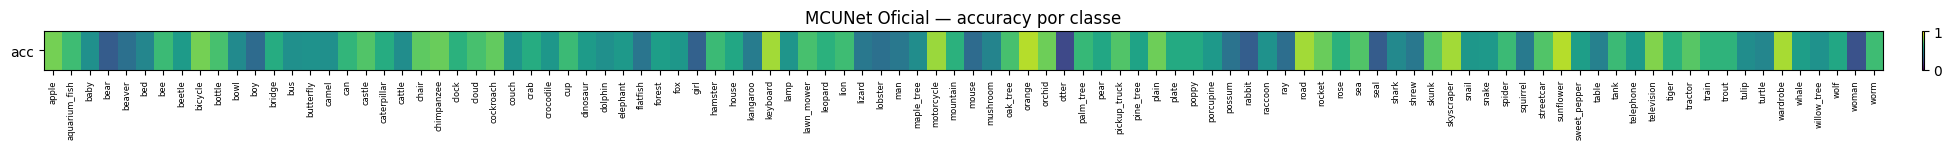

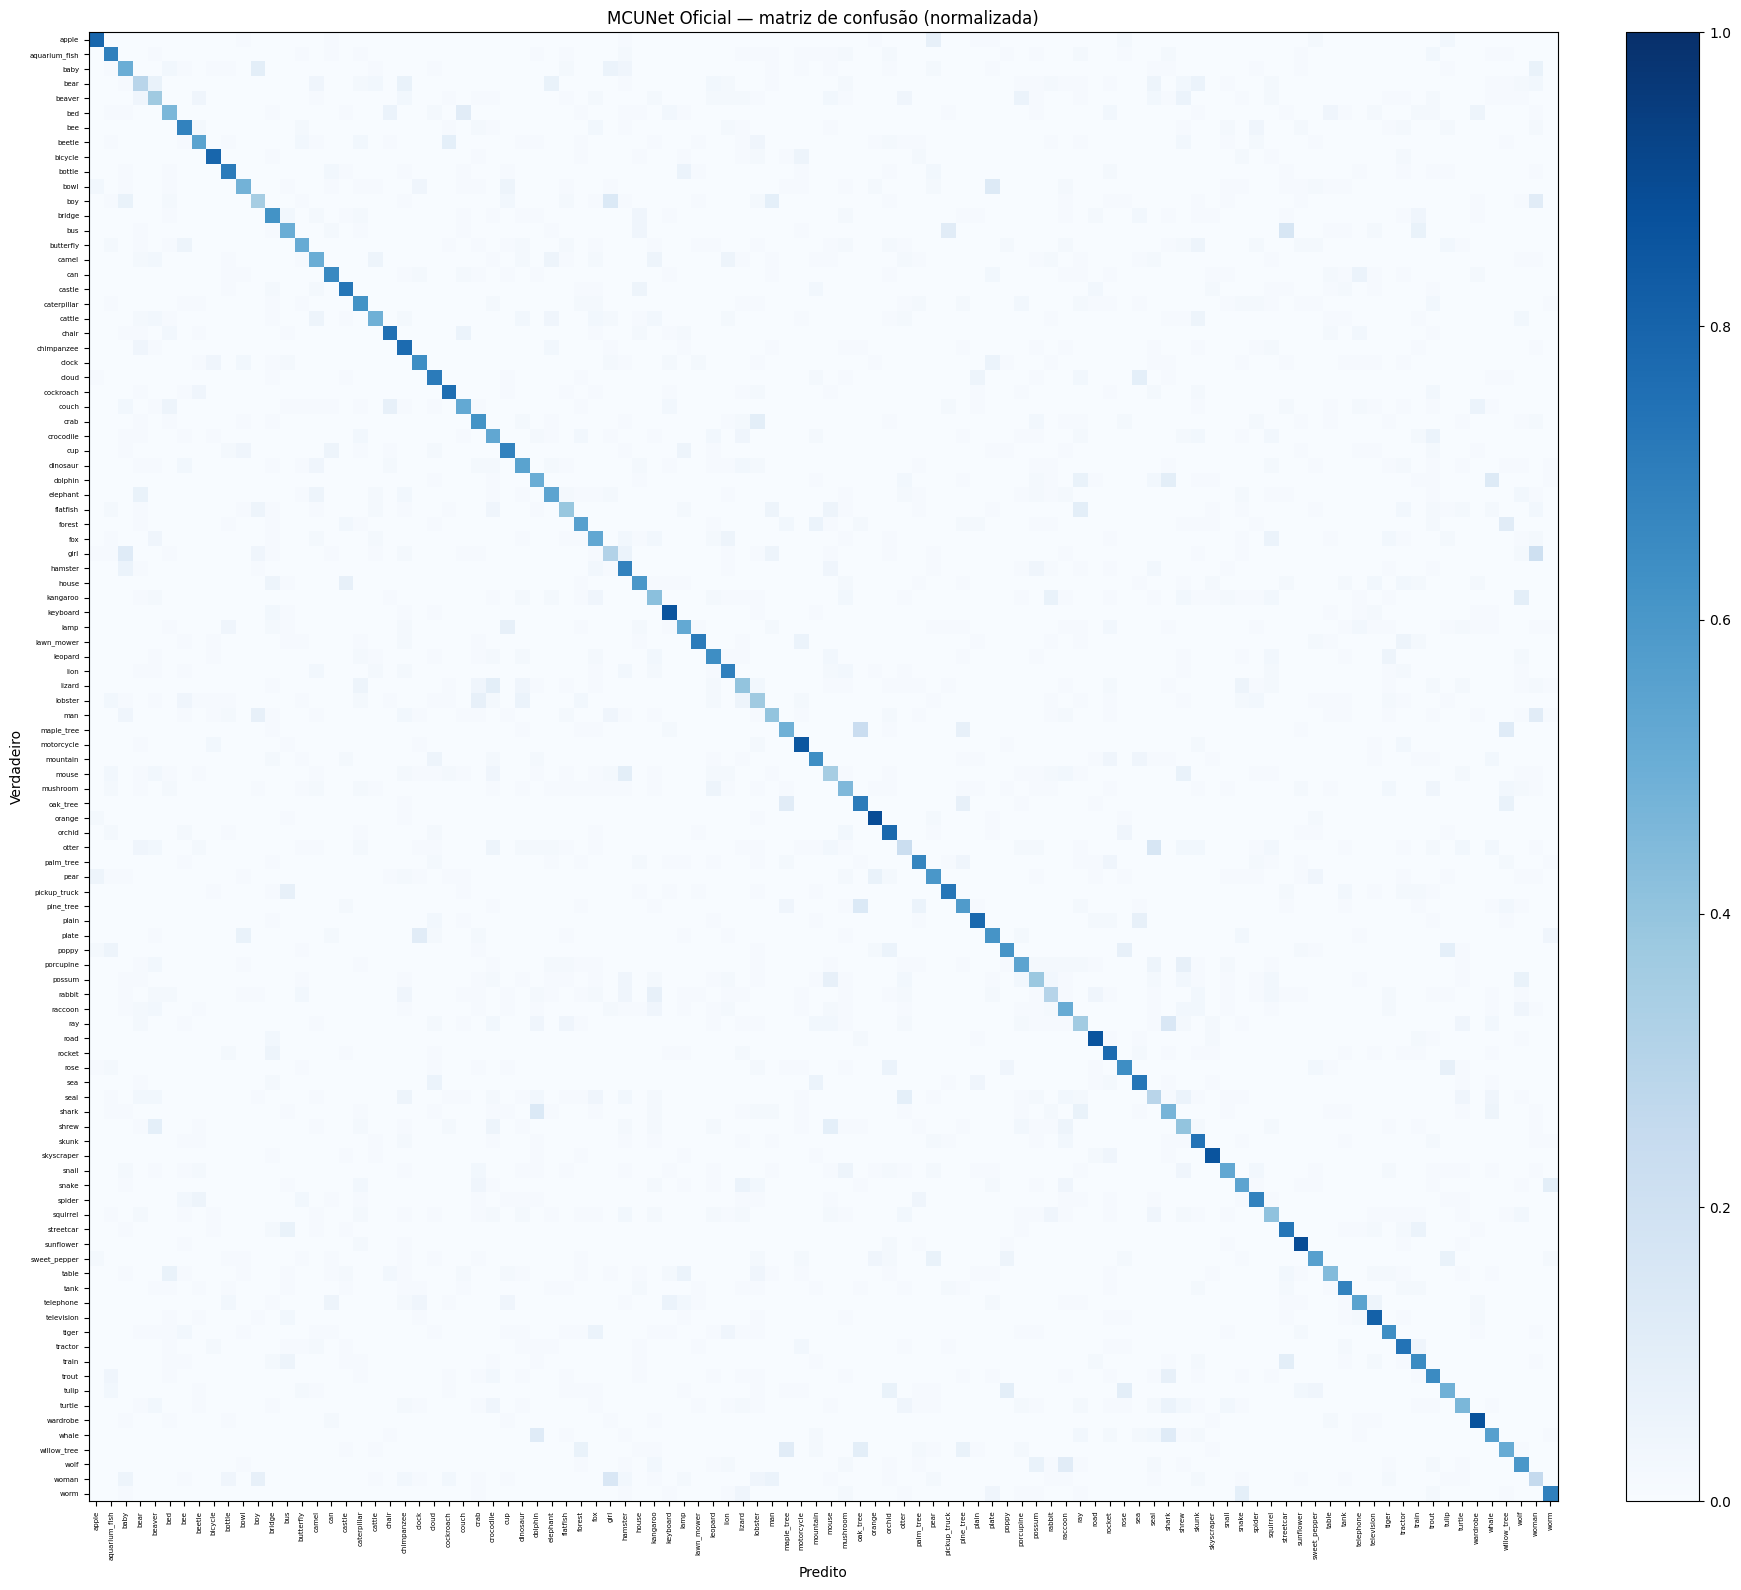

In [8]:
# Salva e avalia MCUNet Oficial
mcunet_off_keras_path, mcunet_off_keras_model = save_best_as_keras(
    build_mcunet_official,
    mcunet_off_results,
    filename="MCUNet_Official_CIFAR100.keras",
)

mcunet_off_eval, mcunet_off_cm = evaluate_model(
    mcunet_off_keras_model, test_ds, class_names, title="MCUNet Oficial"
)

FULL COMPARISON DE TODAS AS VERSÕES DO MCUNet NO CIFAR-10

📊 Analisando: MCUNet (do zero)
[MCUNet (do zero)] accuracy=0.6169 | macro_f1=0.6132 | weighted_f1=0.6132

  10 piores classes:
              otter: acc=0.250 f1=0.286 support=100
               seal: acc=0.250 f1=0.281 support=100
               bear: acc=0.330 f1=0.328 support=100
                man: acc=0.340 f1=0.393 support=100
              mouse: acc=0.340 f1=0.347 support=100
               girl: acc=0.350 f1=0.361 support=100
             rabbit: acc=0.350 f1=0.372 support=100
             lizard: acc=0.370 f1=0.378 support=100
             beaver: acc=0.400 f1=0.402 support=100
              woman: acc=0.420 f1=0.406 support=100

  10 melhores classes:
       pickup_truck: acc=0.830 f1=0.814 support=100
          palm_tree: acc=0.830 f1=0.802 support=100
              skunk: acc=0.830 f1=0.806 support=100
         skyscraper: acc=0.840 f1=0.771 support=100
              chair: acc=0.840 f1=0.800 support=100
          

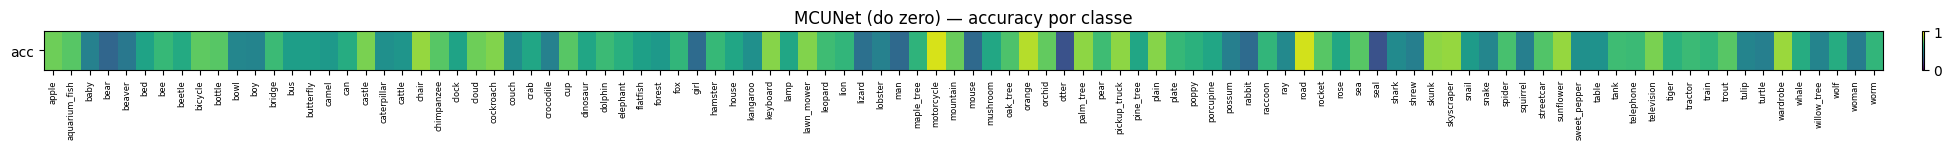

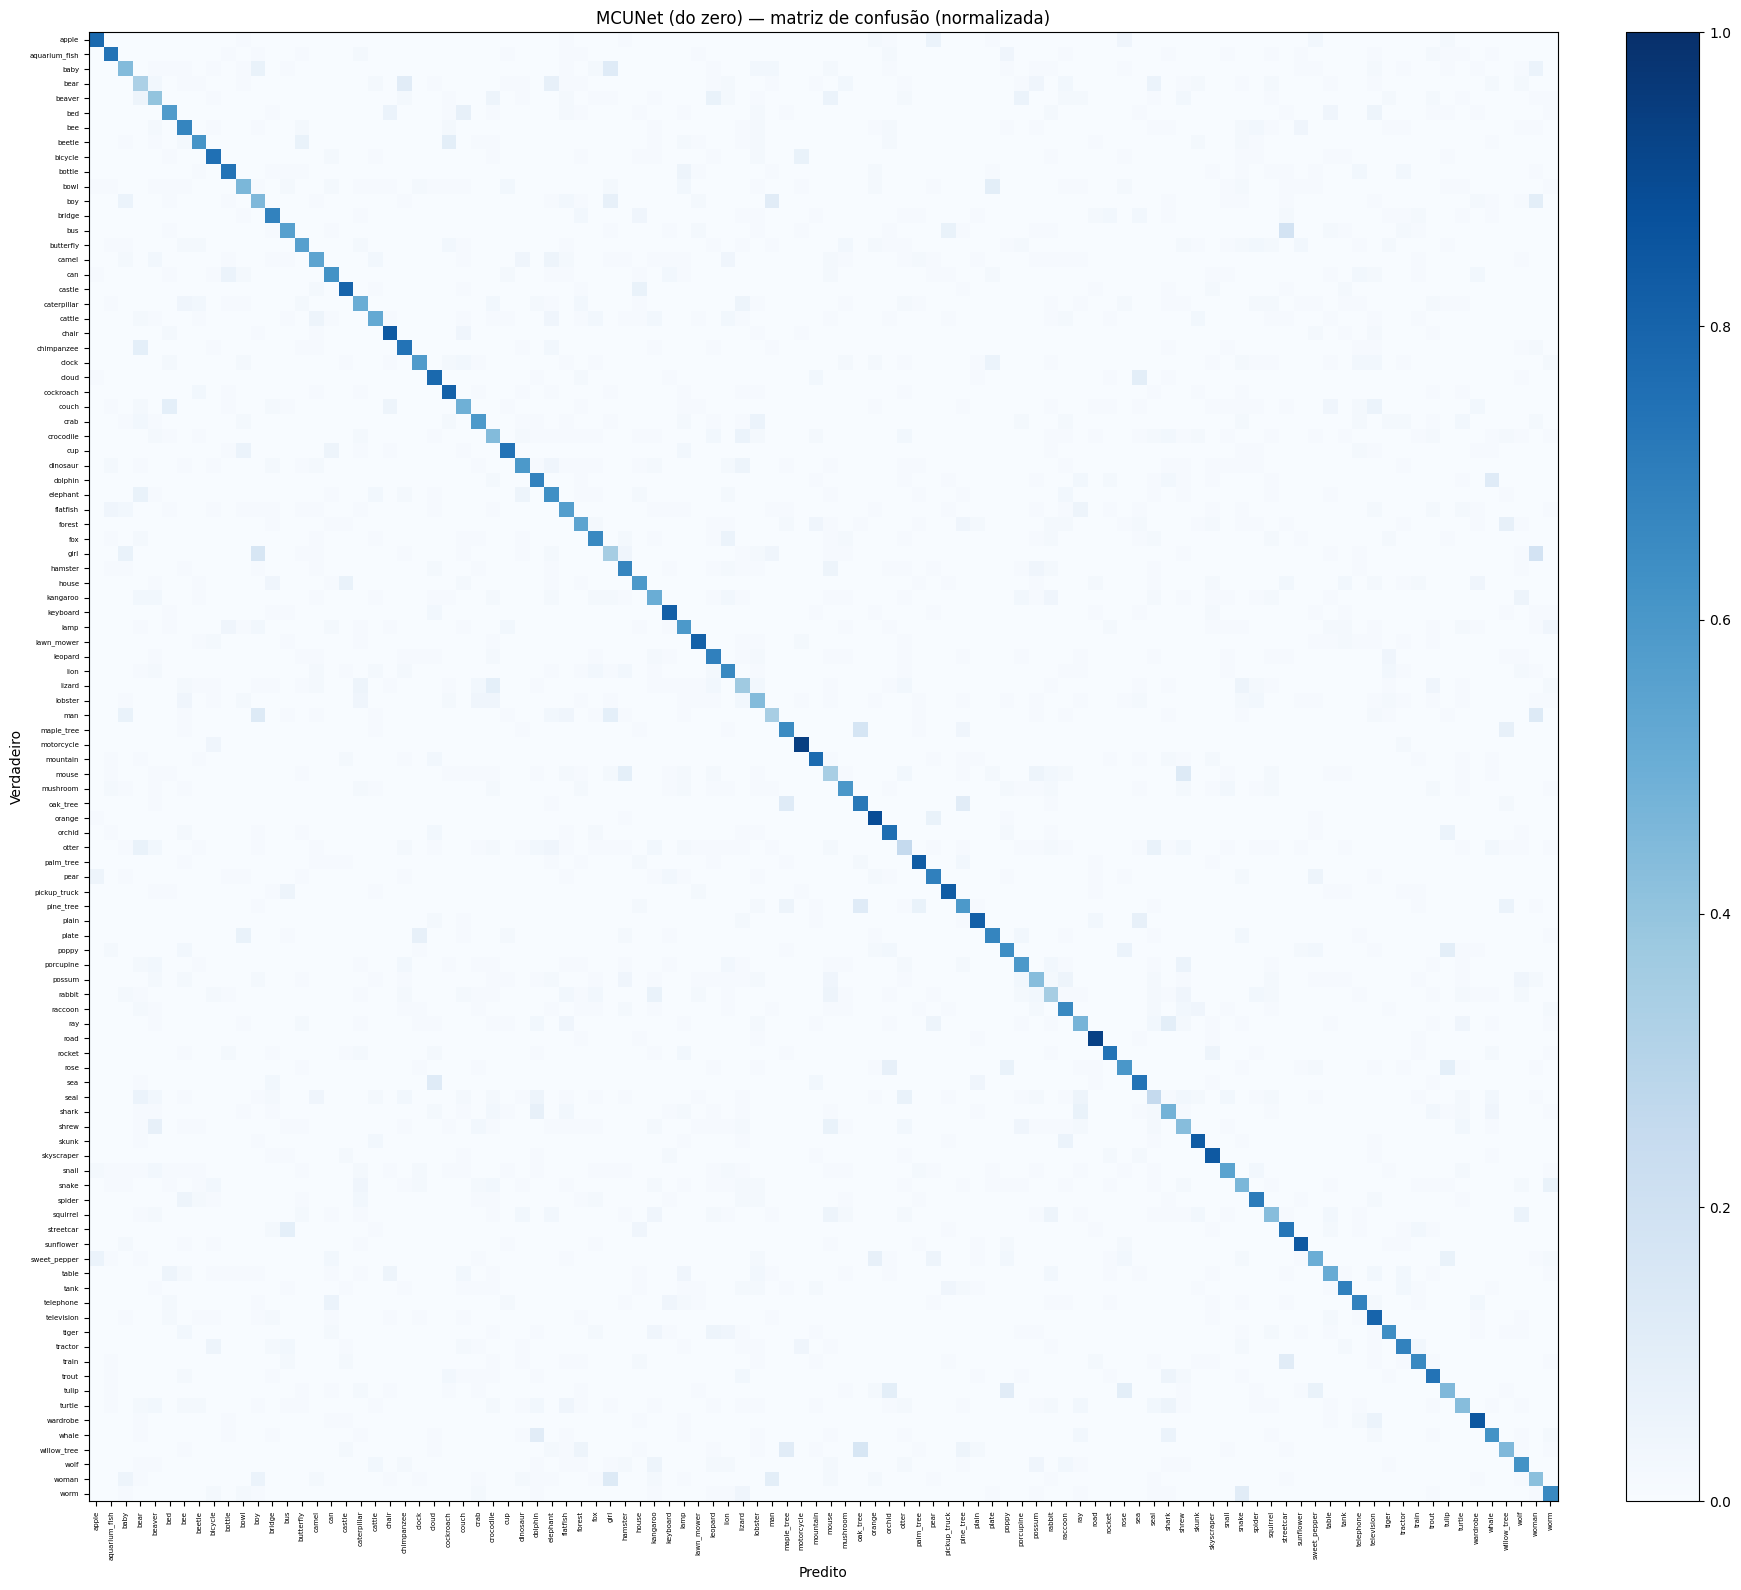

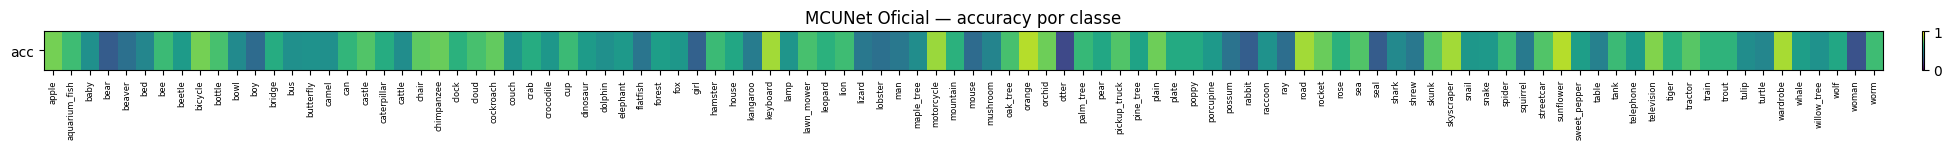

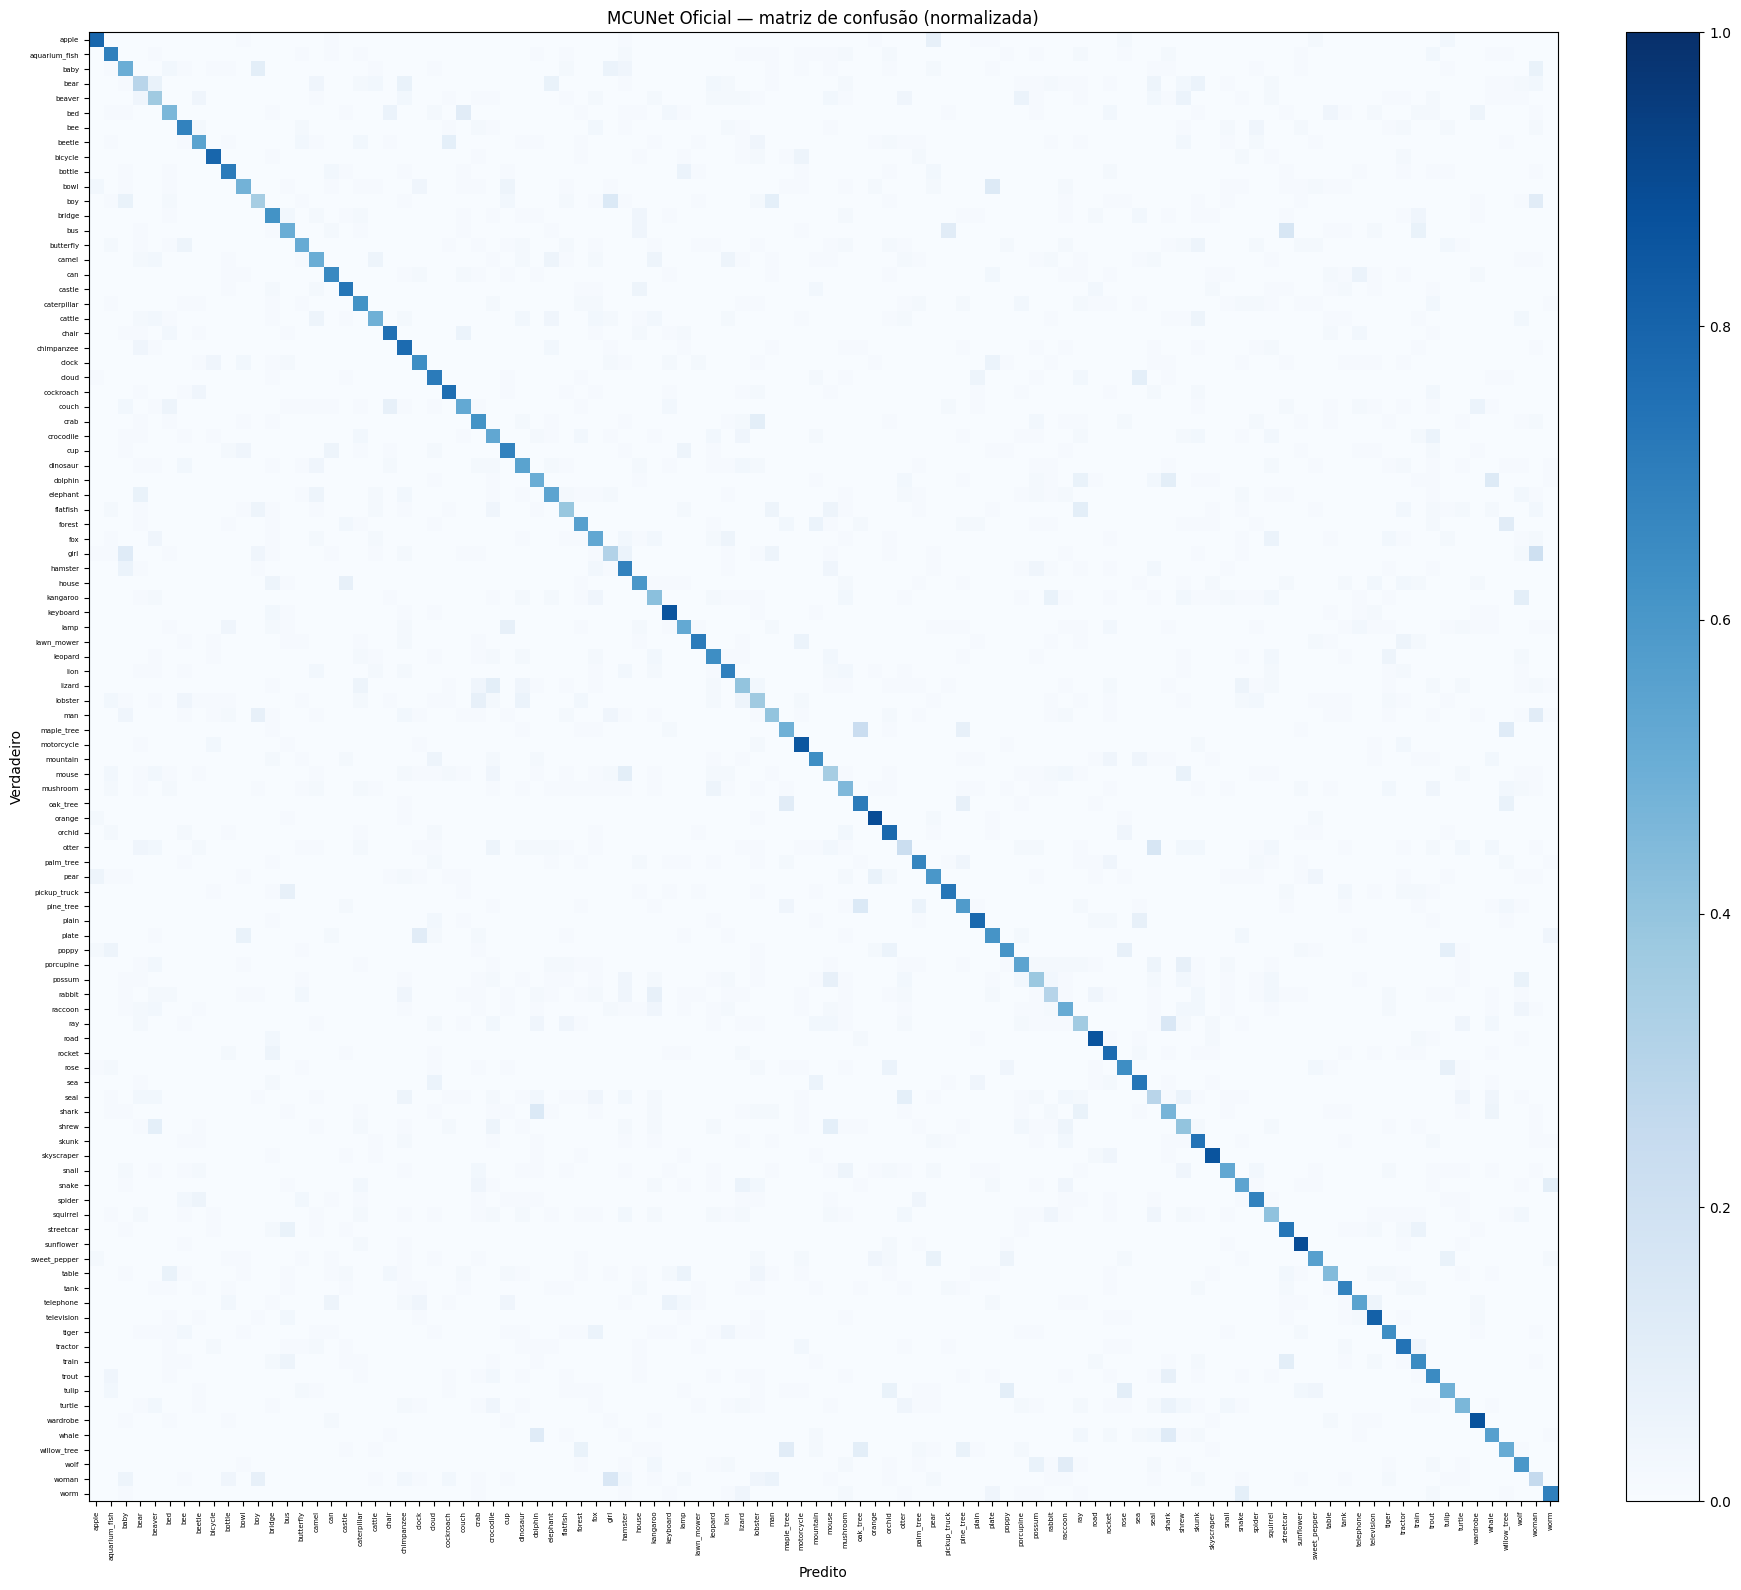

In [6]:
import time
import os

# =====================================================================
# Comparison: all MCUNet variants (accuracy, size, latency)
# =====================================================================

# Register the custom layer if it is not in scope yet
# (necessário para carregar models salvos com camadas customizadas)
if 'ImageNetNormalization' not in dir():
    @tf.keras.utils.register_keras_serializable(package="MCUNet")
    class ImageNetNormalization(layers.Layer):
        """ImageNet normalization: (x/255 - mean) / std"""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
            self.std = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)
        
        def call(self, x):
            x = x / 255.0
            return (x - self.mean) / self.std
        
        def get_config(self):
            return super().get_config()

print("=" * 90)
print("FULL COMPARISON DE TODAS AS VERSÕES DO MCUNet NO CIFAR-10")
print("=" * 90)

# Settings de benchmark
NUM_WARMUP = 5
NUM_RUNS = 50

def measure_model_latency(model, input_shape=(1, 160, 160, 3), num_warmup=5, num_runs=50):
    """Measure Keras model inference latency."""
    dummy_input = np.random.rand(*input_shape).astype(np.float32) * 255
    
    # Warmup
    for _ in range(num_warmup):
        _ = model.predict(dummy_input, verbose=0)
    
    # Measure latency
    latencies = []
    for _ in range(num_runs):
        start = time.perf_counter()
        _ = model.predict(dummy_input, verbose=0)
        end = time.perf_counter()
        latencies.append((end - start) * 1000)  # ms
    
    return {
        'mean_ms': np.mean(latencies),
        'std_ms': np.std(latencies),
        'min_ms': np.min(latencies),
        'p50_ms': np.percentile(latencies, 50),
        'p95_ms': np.percentile(latencies, 95),
    }

def get_model_size_mb(keras_path):
    """Retorna tamanho do arquivo .keras em MB."""
    if Path(keras_path).exists():
        return os.path.getsize(keras_path) / (1024 * 1024)
    return 0.0

def count_model_params(model):
    """Count total and trainable parameters."""
    total = model.count_params()
    trainable = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    return total, trainable

# Models para comparar
mcunet_versions = {
    "MCUNet (do zero)": "keras_models/MCUNet_CIFAR100-512kb-2mb.keras",
    "MCUNet TL (antigo)": "keras_models/MCUNet_TL_CIFAR100.keras",
    "MCUNet Oficial": "keras_models/MCUNet_Official_CIFAR100.keras",
}

# Also include TFLite for a size comparison
tflite_versions = {
    "MCUNet (do zero)": "tflite_models/MCUNet_CIFAR10-512kb-2mb.tflite",
    "MCUNet Oficial": "tflite_models/MCUNet_Official_CIFAR10.tflite",
}

comparison_results = {}

for name, keras_path in mcunet_versions.items():
    path = Path(keras_path)
    if not path.exists():
        print(f"⚠ Model not found: {keras_path}")
        continue
    
    print(f"\n📊 Analisando: {name}")
    
    try:
        # Load model
        model = tf.keras.models.load_model(path)
        
        # Evaluation de accuracy (usa cache se disponível)
        if name == "MCUNet (do zero)" and "mcunet_eval" in dir():
            eval_metrics = mcunet_eval
        elif name == "MCUNet Oficial" and "mcunet_off_eval" in dir():
            eval_metrics = mcunet_off_eval
        elif name == "MCUNet TL (antigo)" and "mcunet_tl_eval" in dir():
            eval_metrics = mcunet_tl_eval
        else:
            eval_metrics, _ = evaluate_model(model, test_ds, class_names, title=name)
        
        # Tamanho do model
        keras_size = get_model_size_mb(keras_path)
        tflite_path = tflite_versions.get(name)
        tflite_size = get_model_size_mb(tflite_path) if tflite_path else 0.0
        
        # Parameters
        total_params, trainable_params = count_model_params(model)
        
        # Latency
        print(f"   Measuring latency ({NUM_RUNS} runs)...")
        latency = measure_model_latency(model, num_warmup=NUM_WARMUP, num_runs=NUM_RUNS)
        
        comparison_results[name] = {
            **eval_metrics,
            'keras_size_mb': keras_size,
            'tflite_size_mb': tflite_size,
            'total_params': total_params,
            'trainable_params': trainable_params,
            'latency_mean_ms': latency['mean_ms'],
            'latency_std_ms': latency['std_ms'],
            'latency_p50_ms': latency['p50_ms'],
            'latency_p95_ms': latency['p95_ms'],
            'fps': 1000 / latency['mean_ms'],
        }
        
        print(f"   ✓ Concluído")
        
    except Exception as e:
        print(f"   ❌ Erro: {e}")

# =====================================================================
# Tabela Comparativa Completa
# =====================================================================
print("\n" + "=" * 100)
print("RESUMO COMPARATIVO - MCUNet (CIFAR-10)")
print("=" * 100)

# Header
print(f"{'Versão':<22s} │ {'Acc':>6s} │ {'F1':>6s} │ {'Params':>8s} │ "
      f"{'Keras':>7s} │ {'TFLite':>7s} │ {'Lat(ms)':>9s} │ {'FPS':>6s}")
print("─" * 100)

for name, m in comparison_results.items():
    params_str = f"{m['total_params']/1e6:.2f}M"
    keras_str = f"{m['keras_size_mb']:.2f}MB"
    tflite_str = f"{m['tflite_size_mb']:.2f}MB" if m['tflite_size_mb'] > 0 else "N/A"
    lat_str = f"{m['latency_mean_ms']:.1f}±{m['latency_std_ms']:.1f}"
    
    print(f"{name:<22s} │ {m['accuracy']:>6.2%} │ {m['macro_f1']:>6.2%} │ {params_str:>8s} │ "
          f"{keras_str:>7s} │ {tflite_str:>7s} │ {lat_str:>9s} │ {m['fps']:>6.1f}")

print("─" * 100)

# Melhor model por categoria
if comparison_results:
    best_acc = max(comparison_results, key=lambda k: comparison_results[k]['accuracy'])
    best_size = min(comparison_results, key=lambda k: comparison_results[k]['keras_size_mb'])
    best_speed = min(comparison_results, key=lambda k: comparison_results[k]['latency_mean_ms'])
    
    print(f"\n🏆 Melhor Accuracy:  {best_acc} ({comparison_results[best_acc]['accuracy']:.2%})")
    print(f"📦 Menor Tamanho:   {best_size} ({comparison_results[best_size]['keras_size_mb']:.2f} MB)")
    print(f"⚡ Mais Rápido:     {best_speed} ({comparison_results[best_speed]['latency_mean_ms']:.1f} ms)")

print("\nNota: Latency medida em CPU do host. Results variam em dispositivos embarcados.")

## Exportar para SavedModel (para depois converter em `.tflite`)

After a kernel restart, variables like `mnv3_results` may be gone — this export path uses **file paths** only.

You can export in two ways:

- **Pelo `.keras`** (recomendado): `keras_models/<nome>.keras`
- **Pelos pesos**: `checkpoints/<tag>_best.weights.h5` (reconstrói o model e carrega os pesos)

O resultado é um **SavedModel** em `saved_models/`, pronto para o `TFLiteConverter`.

In [10]:
import shutil
from pathlib import Path

SAVEDMODEL_DIR = ROOT / "saved_models"
SAVEDMODEL_DIR.mkdir(parents=True, exist_ok=True)


def export_savedmodel_from_keras(keras_path: str, export_name: str):
    model = tf.keras.models.load_model(keras_path)

    out_dir = SAVEDMODEL_DIR / export_name
    if out_dir.exists():
        shutil.rmtree(out_dir)

    # Keras 3: preferir .export(); fallback para tf.saved_model.save
    if hasattr(model, "export"):
        model.export(str(out_dir))
    else:
        tf.saved_model.save(model, str(out_dir))

    print("SavedModel exportado em:", out_dir.resolve())
    return out_dir


models_to_export = [
    ("keras_models/MobileNetV3Small_CIFAR100.keras", "MobileNetV3Small_CIFAR100"),
    ("keras_models/EfficientNetB0_CIFAR100.keras", "EfficientNetB0_CIFAR100"),
    ("keras_models/MCUNet_CIFAR100.keras", "MCUNet_CIFAR100"),
    ("keras_models/MCUNet_Official_CIFAR100.keras", "MCUNet_Official_CIFAR100"),
]

for keras_path, name in models_to_export:
    if Path(keras_path).exists():
        export_savedmodel_from_keras(keras_path, name)
    else:
        print("File not found (skipping):", keras_path)

INFO:tensorflow:Assets written to: saved_models\MobileNetV3Small_CIFAR100\assets


INFO:tensorflow:Assets written to: saved_models\MobileNetV3Small_CIFAR100\assets


Saved artifact at 'saved_models\MobileNetV3Small_CIFAR100'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  2355909508176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2355909507600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2355909507792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2355909507408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2355909508368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2355909508560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2355909506640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2355909506832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2355909505680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2355909508752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  235458272

INFO:tensorflow:Assets written to: saved_models\EfficientNetB0_CIFAR100\assets


Saved artifact at 'saved_models\EfficientNetB0_CIFAR100'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_layer_6')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  2354591299152: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2354591297424: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2354489300688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354586044944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354586043408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354586042448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354586043216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354586042640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354586045904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354586045712: TensorSpec(shape=(), dtype=tf.resource, name=N

INFO:tensorflow:Assets written to: saved_models\MCUNet_CIFAR100\assets


Saved artifact at 'saved_models\MCUNet_CIFAR100'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_layer_9')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  2354591300688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354591300304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354591300112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354591299344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354591300880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354591299728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354591299920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354591298768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354591301072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354591298384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354591300496: Tens

INFO:tensorflow:Assets written to: saved_models\MCUNet_Official_CIFAR100\assets


Saved artifact at 'saved_models\MCUNet_Official_CIFAR100'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  2354581857744: TensorSpec(shape=(3,), dtype=tf.float32, name=None)
  2354581854672: TensorSpec(shape=(3,), dtype=tf.float32, name=None)
  2354581864272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354581863504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354581863696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354581863312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354581856592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354581864080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354581861008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2354581862736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  23545818

## Exportando o conjunto de test (para Android/Raspberry)

Here we store the same **`x_test`/`y_test`** in portable formats for other devices:

- **`cifar100_test_uint8.npz`**: ótimo para reusar em Python (ex.: Raspberry)
- **`images_png/` + `labels.csv`**: fácil de consumir em apps (ex.: Android), usando qualquer leitor de PNG

Tip: for Android, you usually want to export only a **subset** (e.g. 500–2000 images) to keep the app small.

In [12]:
import csv
from pathlib import Path

EXPORT_DIR = ROOT / "exports" / "cifar100"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Quantas imagens exportar.
# - None: exporta tudo (10k)
# - 1000/2000: mais leve pra Android
EXPORT_LIMIT = 2000

n = len(x_test) if EXPORT_LIMIT is None else int(min(EXPORT_LIMIT, len(x_test)))
print("Exportando", n, "imagens de test para", EXPORT_DIR.resolve())

# 1) NPZ (Python/Raspberry)
npz_path = EXPORT_DIR / "cifar100_test_uint8.npz"
np.savez_compressed(
    npz_path,
    x_test=x_test[:n],
    y_test=y_test[:n],
    class_names=np.array(class_names),
)
print("OK:", npz_path)

# 2) PNG + labels.csv (Android/outros)
img_dir = EXPORT_DIR / "images_png"
img_dir.mkdir(parents=True, exist_ok=True)

labels_path = EXPORT_DIR / "labels.csv"
with labels_path.open("w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["filename", "label", "class_name"])
    for i in range(n):
        label = int(y_test[i])
        fname = f"{i:05d}_label{label}.png"
        out_path = img_dir / fname

        # x_test[i] é uint8 (0..255) shape (32,32,3)
        png_bytes = tf.io.encode_png(x_test[i]).numpy()
        tf.io.write_file(str(out_path), png_bytes)

        w.writerow([fname, label, class_names[label]])

print("OK:", img_dir, "(PNGs)")
print("OK:", labels_path)

# Como copiar para dispositivos:
# - Raspberry (scp): scp -r export_cifar100 pi@<ip>:/anonymous/anonymous/
# - Android (adb):   adb push export_cifar100 /sdcard/Download/

Exportando 2000 imagens de test para C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\Lightweight Analyses\export_cifar100
OK: export_cifar100\cifar100_test_uint8.npz
OK: export_cifar100\images_png (PNGs)
OK: export_cifar100\labels.csv


In [7]:
import os

keras_models_dir = ROOT / "keras_models"

model_files = sorted([f for f in keras_models_dir.glob("*CIFAR100*.keras")])
print("Keras model size comparison:")
for f in model_files:
    size_mb = os.path.getsize(f) / (1024*1024)
    print(f"{f.name:35s} {size_mb:8.2f} MB")

Keras model size comparison:
EfficientNetB0_CIFAR100.keras          16.74 MB
MCUNet_CIFAR100-512kb-2mb.keras         6.12 MB
MCUNet_CIFAR100.keras                   2.89 MB
MobileNetV3Small_CIFAR100.keras         4.34 MB


In [14]:
import tensorflow as tf

tflite_models_dir = ROOT / "tflite_models"
tflite_models_dir.mkdir(exist_ok=True)

print("Convertendo models .keras para .tflite:")
for keras_file in model_files:
    model = tf.keras.models.load_model(keras_file)
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    tflite_file = tflite_models_dir / (keras_file.stem + ".tflite")
    with open(tflite_file, "wb") as f:
        f.write(tflite_model)
    size_mb = os.path.getsize(tflite_file) / (1024*1024)
    print(f"{keras_file.name:35s} -> {tflite_file.name:35s} {size_mb:8.2f} MB")
print("Conversão concluída. Models salvos em:", tflite_models_dir)

Convertendo models .keras para .tflite:
INFO:tensorflow:Assets written to: C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\anonymous\anonymous\anonymous\assets


INFO:tensorflow:Assets written to: C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\anonymous\anonymous\anonymous\assets


Saved artifact at 'C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\anonymous\anonymous\tmpoj5g_ddf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_layer_6')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  2357211098064: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2357211101712: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2357472686928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357472686544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357472686736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357472685776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357472686352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357472686160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357472685392: TensorSpec(shape=(), dty

INFO:tensorflow:Assets written to: C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\anonymous\anonymous\anonymous\assets


Saved artifact at 'C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\anonymous\anonymous\tmpjwog1rd4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_layer_9')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  2357472687312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357612362640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357612362832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357274210768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357612363600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357612363408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357612361680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357612361872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357612363216: TensorSpec(shape=(), dtype=tf.resource, na

INFO:tensorflow:Assets written to: C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\anonymous\anonymous\anonymous\assets


Saved artifact at 'C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\anonymous\anonymous\tmpkh9hzebo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  2357273525712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357273525328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357273524944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357273526096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357273525136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357273525904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357494039184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357494039376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2357494038608: TensorSpec(shape=(), dtype=tf.resource, na